In [67]:
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
import statsmodels.api as sm
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [68]:
df = pd.read_csv("sleep_mobile_stress_dataset_15000.csv")

In [69]:
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


### Preprocessing

In [70]:
# Duplicate user check
df[df.duplicated(subset=['user_id'], keep=False)]

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score


In [71]:
# Null check
df.isnull().values.any()

np.False_

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

### Statistical Analysis

In [73]:
df.corr(numeric_only=True)["mental_fatigue_score"].sort_values(ascending=False)

mental_fatigue_score                1.000000
stress_level                        0.948768
daily_screen_time_hours             0.828368
phone_usage_before_sleep_minutes    0.150180
physical_activity_minutes           0.010254
age                                 0.009724
user_id                             0.005458
caffeine_intake_cups               -0.002722
notifications_received_per_day     -0.005077
sleep_duration_hours               -0.011073
sleep_quality_score                -0.808019
Name: mental_fatigue_score, dtype: float64

_Conclusion: Stress level and daily screen time is positively correlated with mental health_

<Axes: xlabel='stress_level', ylabel='mental_fatigue_score'>

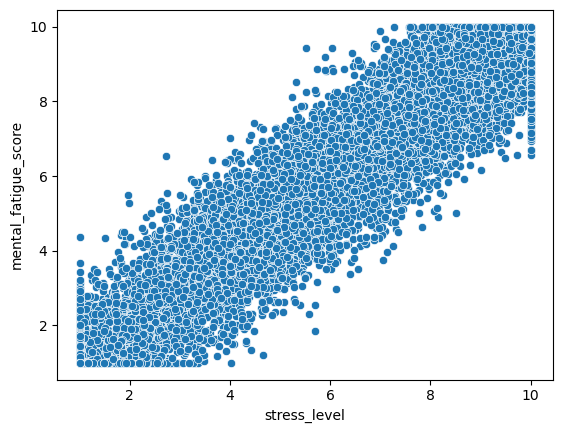

In [74]:
# Scatterplot for comfirmation
sns.scatterplot(
    x = "stress_level",
    y = "mental_fatigue_score",
    data = df
)

<Axes: xlabel='stress_level', ylabel='daily_screen_time_hours'>

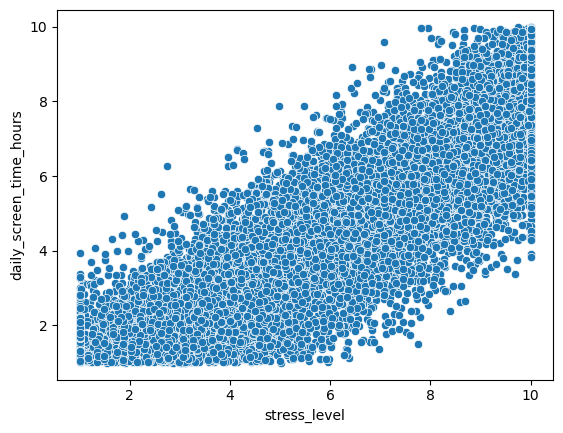

In [75]:
# Scatterplot for confirmation
sns.scatterplot(
    x = "stress_level",
    y = "daily_screen_time_hours",
    data = df
)

Increase in screentime leads to increase in stress level. Therefore, leads to high mental fatigue

In [76]:
pearsonr(df["stress_level"], df["mental_fatigue_score"])

PearsonRResult(statistic=np.float64(0.94876774313667), pvalue=np.float64(0.0))

In [77]:
pearsonr(df["daily_screen_time_hours"], df["mental_fatigue_score"])

PearsonRResult(statistic=np.float64(0.8283680543505194), pvalue=np.float64(0.0))

In [78]:
pearsonr(df["stress_level"], df["daily_screen_time_hours"])

PearsonRResult(statistic=np.float64(0.879001168835814), pvalue=np.float64(0.0))

_Conclusion: p value > 0.05 for all so they are all statistically significant_

In [79]:
# Multiple linear regression
X = df[["stress_level", "daily_screen_time_hours"]]
y = df["mental_fatigue_score"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     mental_fatigue_score   R-squared:                       0.900
Model:                              OLS   Adj. R-squared:                  0.900
Method:                   Least Squares   F-statistic:                 6.771e+04
Date:                  Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                          16:06:18   Log-Likelihood:                -19059.
No. Observations:                 15000   AIC:                         3.812e+04
Df Residuals:                     14997   BIC:                         3.815e+04
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const 

_Conclusion: Model shows good fit_

In [80]:
X = df[[
    "stress_level",
    "daily_screen_time_hours",
    "sleep_duration_hours",
    "sleep_quality_score",
    "physical_activity_minutes"
]]

y = df["mental_fatigue_score"]

import statsmodels.api as sm

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     mental_fatigue_score   R-squared:                       0.900
Model:                              OLS   Adj. R-squared:                  0.900
Method:                   Least Squares   F-statistic:                 2.713e+04
Date:                  Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                          16:06:19   Log-Likelihood:                -19046.
No. Observations:                 15000   AIC:                         3.810e+04
Df Residuals:                     14994   BIC:                         3.815e+04
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
co

No significant increase in model quality

In [81]:
df.groupby("occupation")["mental_fatigue_score"].mean().sort_values(ascending=False)

occupation
Student              7.042198
Manager              6.966682
Software Engineer    6.920292
Doctor               6.872877
Freelancer           6.810153
Teacher              6.810056
Researcher           6.804415
Designer             6.745571
Name: mental_fatigue_score, dtype: float64

In [82]:
df.groupby("occupation")["stress_level"].mean().sort_values(ascending=False)

occupation
Student              7.184879
Manager              7.060031
Software Engineer    7.024262
Doctor               6.968330
Researcher           6.923217
Freelancer           6.899334
Teacher              6.897791
Designer             6.873855
Name: stress_level, dtype: float64

In [83]:
df.groupby("occupation")["daily_screen_time_hours"].mean().sort_values(ascending=False)

occupation
Student              5.634970
Software Engineer    5.550402
Manager              5.543012
Doctor               5.492612
Teacher              5.469950
Researcher           5.455237
Designer             5.451655
Freelancer           5.409471
Name: daily_screen_time_hours, dtype: float64

### Statistical Validation

In [84]:
groups = [g["mental_fatigue_score"].values for name, g in df.groupby("occupation")]

f_oneway(*groups)

F_onewayResult(statistic=np.float64(2.443793732774372), pvalue=np.float64(0.016764769779712856))

There is a statistically significant difference in mental fatigue levels across occupations.

In [85]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    df["mental_fatigue_score"],
    df["occupation"],
    alpha=0.05
)

print(tukey)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
      group1            group2      meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------
         Designer            Doctor   0.1273 0.8461 -0.1436 0.3982  False
         Designer        Freelancer   0.0646 0.9964 -0.2074 0.3365  False
         Designer           Manager   0.2211 0.2011 -0.0484 0.4907  False
         Designer        Researcher   0.0588 0.9981 -0.2151 0.3328  False
         Designer Software Engineer   0.1747 0.5135 -0.0963 0.4458  False
         Designer           Student   0.2966 0.0222  0.0236 0.5697   True
         Designer           Teacher   0.0645 0.9967 -0.2109 0.3399  False
           Doctor        Freelancer  -0.0627 0.9968 -0.3307 0.2053  False
           Doctor           Manager   0.0938 0.9628 -0.1717 0.3593  False
           Doctor        Researcher  -0.0685 0.9946 -0.3384 0.2015  False
           Doctor Software Engineer   

Students have the highest average mental fatigue score among all occupations due to high screen time and high stress. However, the differences between students and most other occupations are not statistically significant, except when compared with designers.

### Machine Learning

In [86]:
features = [
    "stress_level",
    "daily_screen_time_hours",
    "phone_usage_before_sleep_minutes",
    "sleep_quality_score",
    "physical_activity_minutes"
]

In [87]:
X = df[features]
y = df["mental_fatigue_score"]

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [89]:
linear_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

rf_pipe = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])

gbr_pipe = Pipeline([
    ("model", GradientBoostingRegressor(random_state=42))
])

In [90]:
models = {
    "Linear Regression": linear_pipe,
    "Random Forest": rf_pipe,
    "Gradient Boosting": gbr_pipe
}

results = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print(results_df)

               Model        R2       MAE
2  Gradient Boosting  0.902804  0.664616
0  Linear Regression  0.902644  0.656738
1      Random Forest  0.896154  0.686588


_Conclusion: Linear Regression perform best with lowest MAE and R squared is approximately 90,2%_

In [97]:
best_model = linear_pipe
best_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [99]:
# Example current lifestyle
current = pd.DataFrame([{
    "stress_level": 8,
    "daily_screen_time_hours": 9,
    "phone_usage_before_sleep_minutes": 5.5,
    "sleep_quality_score": 4,
    "physical_activity_minutes": 10
}])

# Example improved lifestyle
improved = pd.DataFrame([{
    "stress_level": 5,
    "daily_screen_time_hours": 5,
    "phone_usage_before_sleep_minutes": 7.5,
    "sleep_quality_score": 8,
    "physical_activity_minutes": 45
}])

# Predict using the selected model
current_pred = best_model.predict(current)[0]
improved_pred = best_model.predict(improved)[0]

print("Predicted current mental fatigue:", round(current_pred, 3))
print("Predicted improved mental fatigue:", round(improved_pred, 3))
print("Predicted reduction:", round(current_pred - improved_pred, 3))

Predicted current mental fatigue: 7.655
Predicted improved mental fatigue: 4.978
Predicted reduction: 2.678


Improve lifestyle does lead to improve in mental health